# Iris Flower Classification
**Track:** Data Science | **Task 1**

**Objective:** Train machine learning classification models to identify the species of an iris flower (*Setosa*, *Versicolor*, *Virginica*) from its physical measurements.

**Stack:** Python, scikit-learn, pandas, matplotlib / seaborn, Jupyter Notebook

**Notebook outline**
1. Import libraries
2. Load the dataset
3. Exploratory Data Analysis (EDA)
4. Visualisations
5. Feature selection discussion
6. Train/test split
7. Train classifiers
8. Evaluate each model
9. Best model & justification

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Iris Dataset
The dataset is bundled with scikit-learn, so no download is needed.

In [2]:
iris = load_iris(as_frame=True)

# Combine features and target into a single DataFrame
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")

# Use cleaner column names
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Exploratory Data Analysis (EDA)

### 3.1 Shape

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 150, Columns: 5


### 3.2 Data types

In [4]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

### 3.3 Null value check

In [5]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


### 3.4 Descriptive statistics

In [6]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### 3.5 Class balance

In [7]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Observations**
- 150 samples, 4 numeric features and 1 categorical target.
- No missing values, so no imputation is required.
- Classes are perfectly balanced (50 samples each), so accuracy is a reliable metric here.

## 4. Visualisations

### 4.1 Pairplot: feature distributions and relationships by species

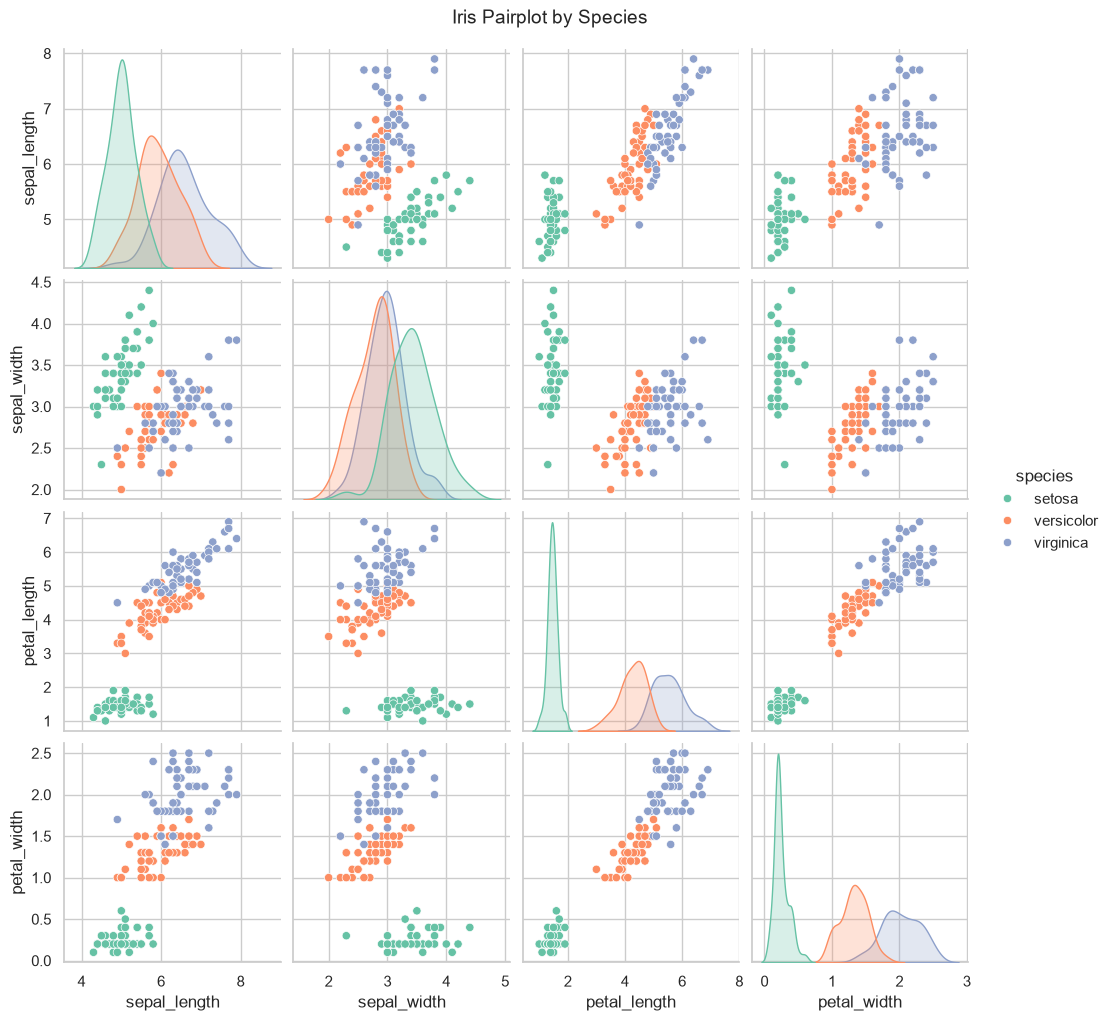

In [8]:
sns.pairplot(df, hue="species", diag_kind="kde", palette="Set2", corner=False)
plt.suptitle("Iris Pairplot by Species", y=1.02, fontsize=14)
plt.show()

### 4.2 Box plots for each feature

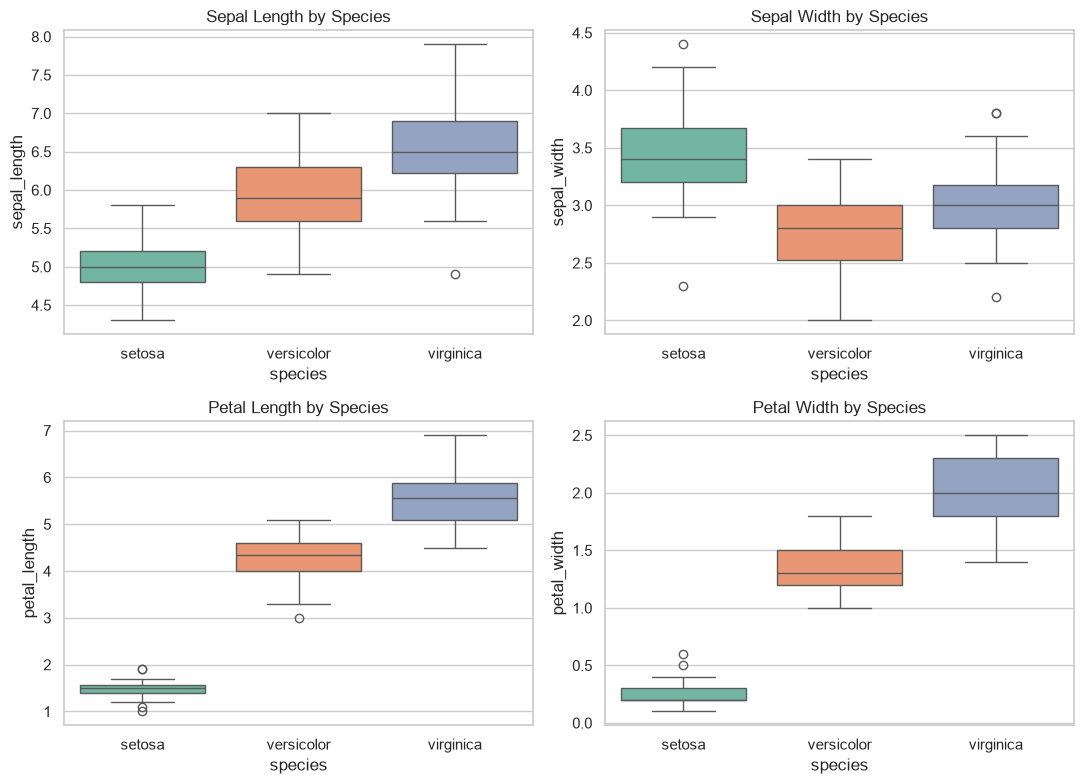

In [9]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="species", y=feat, palette="Set2", ax=ax)
    ax.set_title(f"{feat.replace('_', ' ').title()} by Species")
plt.tight_layout()
plt.show()

### 4.3 Correlation heatmap

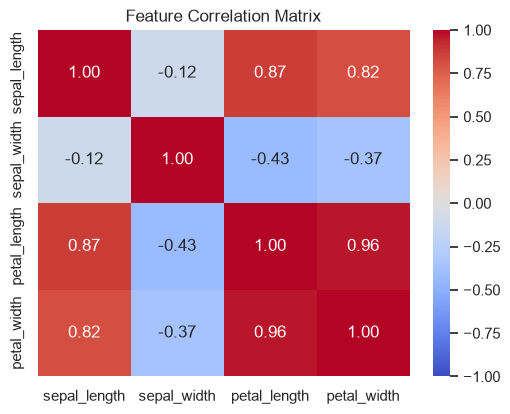

In [10]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

## 5. Feature Selection Discussion
Which features are most discriminative?

petal_length    0.455
petal_width     0.417
sepal_length    0.107
sepal_width     0.021
dtype: float64


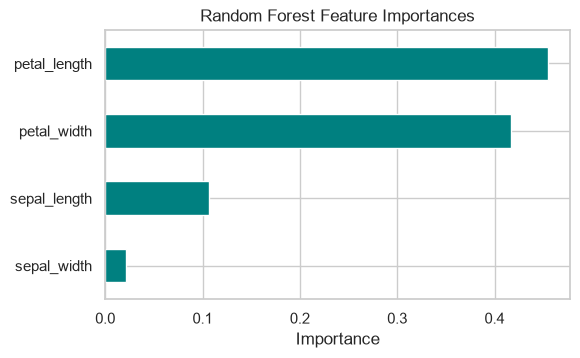

In [11]:
# Quantify how well each feature separates the species using a Random Forest's feature importances
X_all = df[features]
y_all = df["species"]

rf_tmp = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_all, y_all)
importances = pd.Series(rf_tmp.feature_importances_, index=features).sort_values(ascending=False)
print(importances.round(3))

importances.sort_values().plot(kind="barh", color="teal", figsize=(6, 3.5))
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

**Discussion**
- **Petal length** and **petal width** are by far the most discriminative features. In the boxplots, their distributions barely overlap between species, and *Setosa* is completely separable from the others using petals alone.
- **Sepal length** is moderately useful and helps somewhat to separate *Versicolor* from *Virginica*.
- **Sepal width** is the weakest feature, with heavy overlap across all three species.
- Petal length and petal width are also highly correlated (~0.96), so they carry partly redundant information. This is not a problem for tree-based models, but it is worth noting for linear models.
- Because the dataset has only 4 features, we keep **all of them** for modelling; dropping any would gain little and could hurt accuracy.

## 6. Train/Test Split (80/20)
We use `stratify=y` so each species is equally represented in both sets.

In [12]:
X = df[features]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)
print("\nTest class distribution:\n", y_test.value_counts())

Training set: (120, 4)
Test set    : (30, 4)

Test class distribution:
 species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


## 7. Train Classifiers
We train four classifiers. Logistic Regression and KNN are scale-sensitive, so they are wrapped in a pipeline with `StandardScaler` (fitted on training data only, which avoids data leakage). Tree-based models do not need scaling.

In [13]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
    "K-Nearest Neighbours": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: K-Nearest Neighbours
Trained: Decision Tree
Trained: Random Forest


## 8. Evaluate Each Model
For each model: accuracy, confusion matrix and classification report (precision, recall, F1).

Logistic Regression
Test accuracy : 0.9333
5-fold CV acc : 0.9600

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



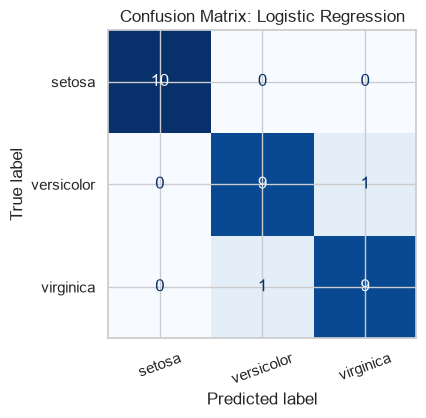

K-Nearest Neighbours
Test accuracy : 0.9333
5-fold CV acc : 0.9600

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



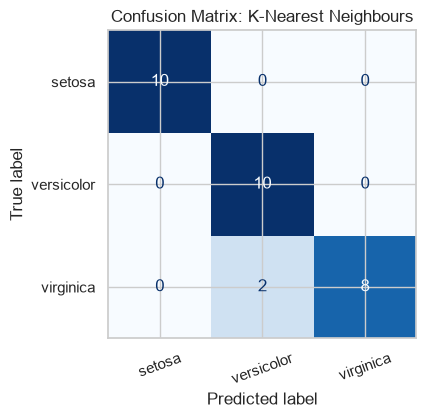

Decision Tree
Test accuracy : 0.9333
5-fold CV acc : 0.9533

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



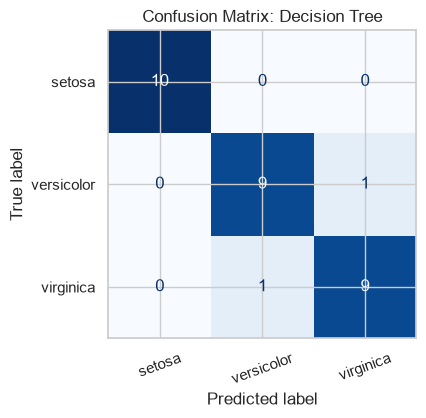

Random Forest
Test accuracy : 0.9000
5-fold CV acc : 0.9667

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



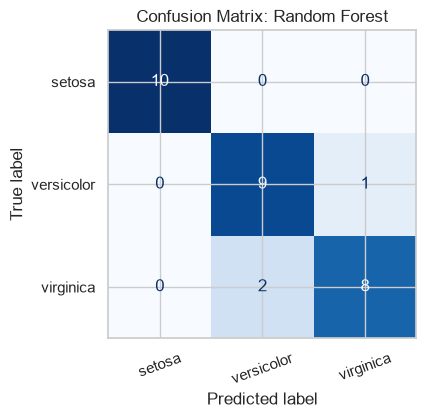

In [14]:
class_names = list(iris.target_names)
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5).mean()   # 5-fold CV as a more robust check
    results[name] = {"Test Accuracy": acc, "5-Fold CV Accuracy": cv}

    print("=" * 60)
    print(f"{name}")
    print("=" * 60)
    print(f"Test accuracy : {acc:.4f}")
    print(f"5-fold CV acc : {cv:.4f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    plt.xticks(rotation=20)
    plt.show()

### Model comparison

,Test Accuracy,5-Fold CV Accuracy
Logistic Regression,0.9333,0.9600
K-Nearest Neighbours,0.9333,0.9600
Decision Tree,0.9333,0.9533
Random Forest,0.9000,0.9667


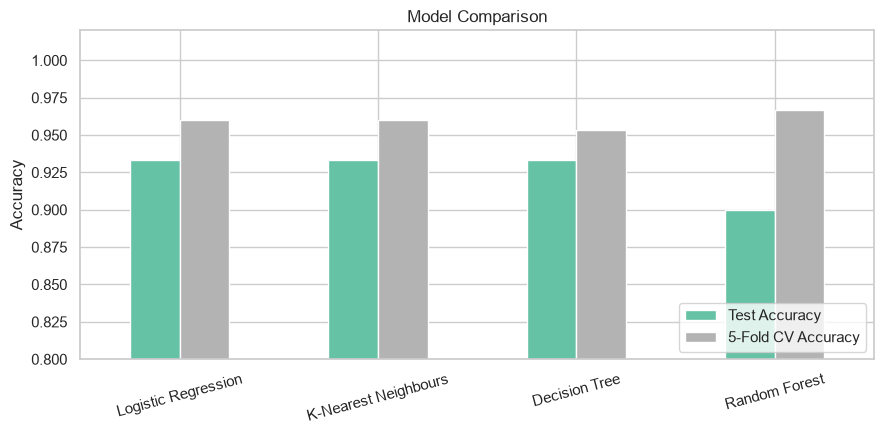

In [15]:
results_df = pd.DataFrame(results).T.sort_values("Test Accuracy", ascending=False).round(4)
display(results_df)

results_df.plot(kind="bar", figsize=(9, 4.5), colormap="Set2", rot=15)
plt.ylim(0.8, 1.02)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Best-Performing Model

In [16]:
# Rank by CV accuracy first (more stable than a single 30-sample test split), then test accuracy
best_name = results_df.sort_values(["5-Fold CV Accuracy", "Test Accuracy"], ascending=False).index[0]
print(f"Best model: {best_name}")
print(results_df.loc[best_name])

Best model: Random Forest
Test Accuracy         0.9000
5-Fold CV Accuracy    0.9667
Name: Random Forest, dtype: float64


### Justification
- All four classifiers perform well (about 90-93% on the held-out test set, 95-97% in cross-validation) because the Iris classes are well separated, especially by the petal features.
- The test set holds only 30 samples, so a single misclassified flower shifts accuracy by about 3.3 points. Three models tie at 93.3% and Random Forest scores 90.0%, a gap of just one flower, so the test split alone cannot separate them.
- I therefore rank by **5-fold cross-validation accuracy**, which averages over all 150 samples and is more stable. By that measure **Random Forest** comes out on top (about 96.7%), ahead of Logistic Regression and KNN (96.0%) and the Decision Tree (95.3%).
- Setosa is always classified correctly; every error is between *Versicolor* and *Virginica*, which overlap slightly in feature space.
- **Caveat:** the differences between the top models are tiny (about one flower) and not statistically meaningful. Random Forest is declared best on the more robust CV evidence, but Logistic Regression or KNN would be an equally defensible, simpler choice for a dataset this small and clean.

## Conclusion
- EDA showed a clean, balanced dataset with no missing values.
- Petal length and petal width are the most discriminative features.
- Four classifiers were trained and evaluated with accuracy, confusion matrices, classification reports and cross-validation.
- The best-performing model was declared with justification in Section 9.